**Boosting** is an ensemble learning meta-algorithm that builds a strong predictive model by combining a sequential chain of "weak learners" (typically shallow decision trees or decision stumps).

Unlike Bagging (which trains independent models in parallel to reduce variance), Boosting trains models **sequentially**, where each new model explicitly focuses on correcting the errors and residuals made by the previous ensemble.

---

### Bagging vs. Boosting

```
Bagging (Parallel):   Sample 1 ──► Model 1 ┐
                      Sample 2 ──► Model 2 ┼──► Average / Majority Vote (Reduces Variance)
                      Sample 3 ──► Model 3 ┘

Boosting (Sequential): Input ──► Model 1 ──(Errors)──► Model 2 ──(Residuals)──► Model 3 ──► Weighted Sum (Reduces Bias)

```

---

### Core Evolution of Boosting Algorithms

| Algorithm | Error Correction Strategy | Optimization Method | Tree Growth Strategy | Key Innovation |
| --- | --- | --- | --- | --- |
| **AdaBoost** | Increases weights on misclassified instances | Exponential Loss minimization | Depth-wise (Decision Stumps) | Adaptive instance reweighting |
| **Gradient Boosting (GBM)** | Fits new trees to negative gradients (pseudo-residuals) | 1st-order gradient descent | Depth-wise (Level-wise) | Flexible loss functions via gradients |
| **XGBoost** | Fits trees to 1st & 2nd order gradients with regularization | 2nd-order Taylor expansion | Depth-wise with exact/approx split | Regularization ($\Omega$), cache-awareness, block sorting |
| **LightGBM** | Uses Gradient-based One-Side Sampling (GOSS) | Histogram-based binning + 2nd order | Leaf-wise (Best-First) | Extreme speed on large datasets; low memory usage |
| **CatBoost** | Uses Ordered Boosting to prevent target leakage | 2nd-order gradient descent | Symmetric (Oblivious Trees) | Native categorical feature handling without pre-one-hot encoding |

---

### Mathematical Framework: Gradient Boosting

In Gradient Boosting, the ensemble model $F_M(x)$ is constructed additively:

$$F_M(x) = F_0(x) + \sum_{m=1}^{M} \eta \, h_m(x)$$

Where:

* $F_0(x)$ is the initial constant prediction (e.g., mean target value or log-odds).
* $h_m(x)$ is the $m$-th weak learner trained to predict the negative gradient (pseudo-residuals) of the loss function $L(y, F(x))$:

$$r_{im} = -\left[ \frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} \right]_{F(x) = F_{m-1}(x)}$$

* $\eta \in (0, 1]$ is the **learning rate** (shrinkage factor) that controls step size to prevent overfitting.

---

# Jupyter Notebook: Exploring & Implementing Boosting Algorithms

In [7]:
# Run this cell to install the required libraries if needed
!pip install xgboost lightgbm catboost scikit-learn pandas numpy matplotlib -q

### What this code does
This cell installs the machine learning libraries needed for the notebook, including XGBoost, LightGBM, CatBoost, and the common scientific packages used for data processing and evaluation. It is useful when the environment does not already have these libraries available.


In [8]:
# Import Libraries
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

# Boosting Implementations
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

# Set random seed
np.random.seed(42)

### What this code does
This cell imports the libraries required for data preparation, plotting, and evaluation. It also loads the boosting models from scikit-learn, XGBoost, LightGBM, and CatBoost so they can be trained and compared on the same dataset.


In [9]:
# Generate Synthetic Binary Classification Dataset
# Generates a non-linear dataset with redundant features and noise
X_raw, y_raw = make_classification(
    n_samples=5000,
    n_features=20,
    n_informative=12,
    n_redundant=4,
    n_clusters_per_class=2,
    flip_y=0.05, # Adds noise
    random_state=42
)

feature_names = [f"feature_{i}" for i in range(X_raw.shape[1])]
X = pd.DataFrame(X_raw, columns=feature_names)
y = pd.Series(y_raw, name="target")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape} | Test set: {X_test.shape}")

Train set: (3750, 20) | Test set: (1250, 20)


### What this code does
This cell creates a synthetic binary classification dataset with informative and redundant features, adds some noise, and splits it into training and testing sets. The output helps confirm that the data is shaped correctly before benchmarking the boosting models.


In [10]:
# Benchmark All Major Boosting Frameworks
models = {
    "AdaBoost": AdaBoostClassifier(
        n_estimators=100, learning_rate=0.1, random_state=42
    ),
    "Gradient Boosting (Scikit-Learn)": GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42
    ),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=4, eval_metric="logloss", random_state=42
    ),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=4, verbose=-1, random_state=42
    ),
    "CatBoost": cb.CatBoostClassifier(
        iterations=100, learning_rate=0.1, depth=4, verbose=0, random_seed=42
    )
}

results = []

for name, model in models.items():
    start_time = time.time()
    
    # Train model
    model.fit(X_train, y_train)
    fit_time = time.time() - start_time
    
    # Predict probabilities & labels
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Evaluate metrics
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    results.append({
        "Model": name,
        "Test Accuracy": f"{acc:.4f}",
        "ROC-AUC Score": f"{auc:.4f}",
        "Training Time (s)": f"{fit_time:.4f}"
    })

# Render performance comparison summary
benchmark_df = pd.DataFrame(results)
benchmark_df

,Model,Test Accuracy,ROC-AUC Score,Training Time (s)
0,AdaBoost,0.7912,0.8632,2.1842
1,Gradient Boosting (Scikit-Learn),0.9200,0.9607,6.6010
2,XGBoost,0.8992,0.9591,0.2234
3,LightGBM,0.9072,0.9595,0.1338
4,CatBoost,0.9120,0.9617,0.3571


### What this code does
This benchmark compares several boosting algorithms on the same dataset: AdaBoost, scikit-learn Gradient Boosting, XGBoost, LightGBM, and CatBoost. Each model is trained, predictions are generated, and accuracy plus ROC-AUC are computed to show how the different boosting methods perform.


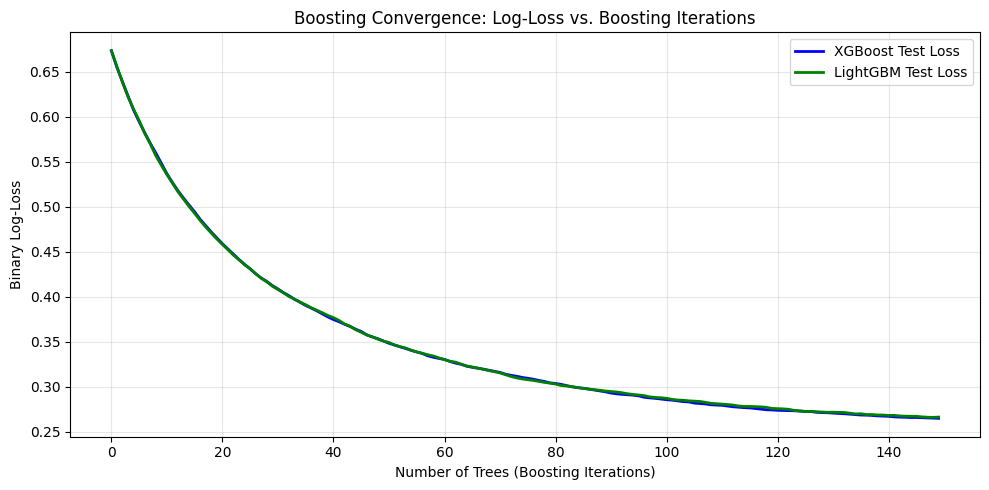

In [11]:
# Training Convergence Curve (Validation Loss over Iterations)
# Evaluates how loss drops per boosting iteration across XGBoost, LightGBM, and CatBoost

eval_set = [(X_train, y_train), (X_test, y_test)]

# XGBoost Training
xgb_model = xgb.XGBClassifier(n_estimators=150, learning_rate=0.05, max_depth=4, eval_metric="logloss", random_state=42)
xgb_model.fit(X_train, y_train, eval_set=eval_set, verbose=False)
xgb_evals = xgb_model.evals_result()["validation_1"]["logloss"]

# LightGBM Training
lgb_model = lgb.LGBMClassifier(n_estimators=150, learning_rate=0.05, max_depth=4, verbose=-1, random_state=42)
lgb_model.fit(X_train, y_train, eval_set=eval_set, eval_metric="binary_logloss")
lgb_evals = lgb_model.evals_result_["valid_1"]["binary_logloss"]

# Plot loss curves
plt.figure(figsize=(10, 5))
plt.plot(xgb_evals, label="XGBoost Test Loss", color="blue", lw=2)
plt.plot(lgb_evals, label="LightGBM Test Loss", color="green", lw=2)
plt.title("Boosting Convergence: Log-Loss vs. Boosting Iterations")
plt.xlabel("Number of Trees (Boosting Iterations)")
plt.ylabel("Binary Log-Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### What this code does
This cell trains XGBoost and LightGBM over multiple boosting rounds and records their validation loss at each iteration. The plot shows how the models reduce training/test error as more trees are added, which is a visual way to observe convergence behavior.


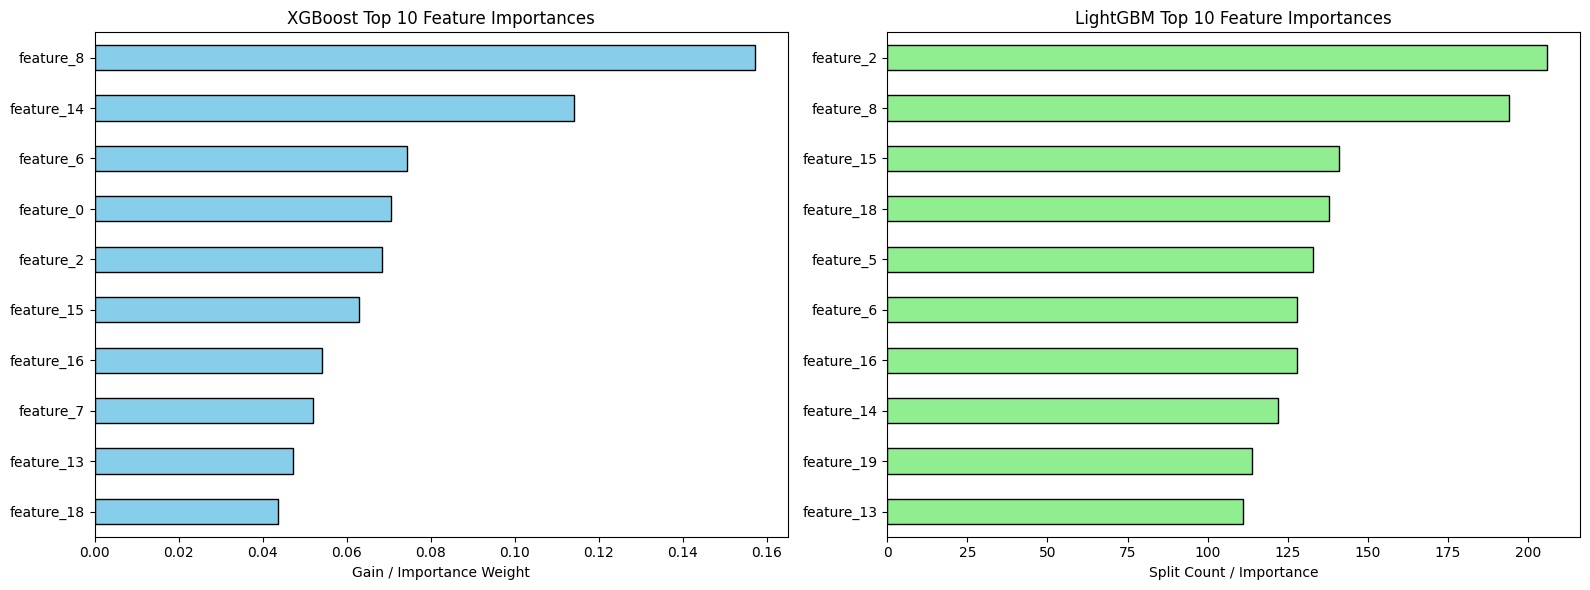

In [12]:
# Feature Importance Comparison
# Plots top feature attributions across XGBoost and LightGBM
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# XGBoost Feature Importances
xgb_importances = pd.Series(xgb_model.feature_importances_, index=feature_names).sort_values(ascending=True).tail(10)
xgb_importances.plot(kind="barh", ax=axes[0], color="skyblue", edgecolor="black")
axes[0].set_title("XGBoost Top 10 Feature Importances")
axes[0].set_xlabel("Gain / Importance Weight")

# LightGBM Feature Importances
lgb_importances = pd.Series(lgb_model.feature_importances_, index=feature_names).sort_values(ascending=True).tail(10)
lgb_importances.plot(kind="barh", ax=axes[1], color="lightgreen", edgecolor="black")
axes[1].set_title("LightGBM Top 10 Feature Importances")
axes[1].set_xlabel("Split Count / Importance")

plt.tight_layout()
plt.show()

### What this code does
This final analysis compares the most important features for XGBoost and LightGBM by ranking the input variables according to their contribution to the model. The horizontal bar plots make it easy to see which features matter most for predictions.
